# 00b — EDA y limpieza del panel distrital (`panel_distrital_final.csv`)

**Qué se hace en este notebook:** antes de usar `panel_distrital_final.csv` en el modelo causal, lo revisamos a fondo — nulos, duplicados, consistencia interna, outliers y distribuciones — y aplicamos las correcciones que quedaron pendientes de la validación de la sesión anterior (documentadas en `causal-anemia-model_hallazgos_eda_validacion.md`).

**Por qué se hace:** el panel viene de unir 8 fuentes distintas (satelitales, administrativas, censales) con años de cobertura distintos y decisiones de codificación tomadas en momentos distintos. Un `NaN` puede significar "no aplica", "no se midió ese año" o "hubo un bug al procesar la fuente" — y cada caso exige una decisión distinta (dejarlo como está, imputar, o corregir el pipeline). Este notebook documenta esa decisión para cada caso, en vez de aplicar una regla genérica (ej. "rellenar todo con la media") que escondería el problema real.

**Qué corrige puntualmente este notebook** (hallazgos de la validación anterior):
1. Elimina los distritos que no calzan con la geobase territorial (sin esto, quedan filas sin ningún dato de contexto satelital, inútiles para el modelo de visión por computadora).
2. Corrige un bug de decodificación real en RENAMU: el marcador `"#¡NULO!"` (sin respuesta) se estaba codificando como `"No"` en vez de como dato faltante, en `programa_anemia` (2023) y `centro_salud_municipal` (2022).
3. Aplica el desfase de año retrospectivo de RENAMU que quedó pendiente desde el notebook original (`00g_renamu.ipynb`).
4. Deja documentada (sin borrar) la columna `region`, que pese a su nombre no contiene costa/sierra/selva sino una copia de `departamento`.

**Salida:** `data/clean/merged/panel_distrital_clean.csv` — el `_final.csv` original no se modifica, para no perder trazabilidad del pipeline.


## 0. Setup

**Qué se hace:** cargar librerías y resolver la ruta a la carpeta `data/` del proyecto.

**Por qué así:** los demás notebooks del proyecto (`00a`-`00i`) usan una función `find_project_root()` que busca hacia arriba hasta encontrar `requirements.txt`. Acá, para mantener el código simple y sin funciones, aprovechamos que la ubicación de este notebook dentro del repo es fija (`notebooks/02_anemia_and_spending_models/00b_EDA.ipynb`) y subimos manualmente dos niveles.


In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Este notebook vive en notebooks/02_anemia_and_spending_models/,
# la raíz del repo está dos niveles arriba.
PROJECT_ROOT = Path.cwd().parent.parent
DATA = PROJECT_ROOT / "data"

CLEAN_CSV_PATH = DATA / "clean" / "panel_distrital.csv"
MERGED_CSV_PATH = DATA / "clean" / "merged" / "panel_distrital_final.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Existe el CSV de entrada:", MERGED_CSV_PATH.exists())


PROJECT_ROOT: c:\Users\JHOSSEP\Documents\REPO\causal-anemia-model
Existe el CSV de entrada: True


## 1. Carga y primer vistazo

**Qué se hace:** cargar el panel y mirar su forma antes de tocar nada — cuántas filas, cuántas columnas, qué tipo de dato tiene cada una.

**Por qué:** es el paso más simple y el más importante para no trabajar a ciegas. En particular, `ubigeo` se carga explícitamente como texto (`dtype=str`) porque varias fuentes lo traen como número, lo que le come el cero a la izquierda de los departamentos 01-09 (ej. `010101` se convierte en `10101`).


In [2]:
df = pd.read_csv(MERGED_CSV_PATH, dtype={"ubigeo": str})

print("Shape:", df.shape)
print()
print("Ejemplo de ubigeo (debe tener 6 caracteres, con cero a la izquierda si aplica):")
print(df["ubigeo"].head(3).tolist())
df.head()


Shape: (13148, 36)

Ejemplo de ubigeo (debe tener 6 caracteres, con cero a la izquierda si aplica):
['010101', '010101', '010101']


,ubigeo,anio,ninos_evaluados,ninos_con_anemia,ninos_sin_anemia,prevalencia_anemia,gasto_total,gasto_anemia_pan,personal_total,programa_anemia,...,pct_agua_visible,n_edificios,area_construida_m2,confianza_media,area_distrito_km2,densidad_edificios_km2,elevacion_media,pendiente_media,pct_agua_permanente,pct_agua_estacional
0,010101,2020,245.0,85.0,160.0,0.346939,NaN,NaN,NaN,NaN,...,0.000107,16298.0,1.306565e+06,0.783185,153.795602,105.971821,2423.265986,21.252837,0.019574,0.44859
1,010101,2021,234.0,71.0,163.0,0.303419,7.452997e+08,44747568.78,208.0,1.0,...,0.000107,16298.0,1.306565e+06,0.783185,153.795602,105.971821,2423.265986,21.252837,0.019574,0.44859
2,010101,2022,201.0,76.0,125.0,0.378109,7.182696e+08,10204248.58,198.0,0.0,...,0.000107,16298.0,1.306565e+06,0.783185,153.795602,105.971821,2423.265986,21.252837,0.019574,0.44859
3,010101,2023,837.0,160.0,677.0,0.191159,9.745361e+08,0.00,206.0,1.0,...,0.000107,16298.0,1.306565e+06,0.783185,153.795602,105.971821,2423.265986,21.252837,0.019574,0.44859
4,010101,2024,969.0,157.0,812.0,0.162023,1.002462e+09,0.00,268.0,1.0,...,0.000107,16298.0,1.306565e+06,0.783185,153.795602,105.971821,2423.265986,21.252837,0.019574,0.44859


In [3]:
df.dtypes


ubigeo                        str
anio                        int64
ninos_evaluados           float64
ninos_con_anemia          float64
ninos_sin_anemia          float64
prevalencia_anemia        float64
gasto_total               float64
gasto_anemia_pan          float64
personal_total            float64
programa_anemia           float64
centro_salud_municipal    float64
departamento                  str
provincia                     str
distrito                      str
region                        str
macroregion_inei              str
macroregion_minsa             str
capital                       str
latitude                  float64
longitude                 float64
altitude                  float64
superficie                float64
pob_densidad_2020         float64
pct_cultivo               float64
pct_construido            float64
pct_desnudo               float64
pct_agua_visible          float64
n_edificios               float64
area_construida_m2        float64
confianza_medi

## 2. Nulos

**Qué se hace:** contar cuántos nulos tiene cada columna, en número y en porcentaje.

**Por qué:** antes de decidir si imputamos, eliminamos o dejamos un nulo tal cual, necesitamos saber cuánto pesa cada uno. Un 0.07% de nulos (9 filas) es un caso puntual a documentar; un 44% de nulos (como en `personal_total`) es una limitación estructural de cobertura temporal de la fuente, no un error.


In [4]:
n_nulos = df.isnull().sum()
pct_nulos = (n_nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({"n_nulos": n_nulos, "pct_nulos": pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos["n_nulos"] > 0].sort_values("n_nulos", ascending=False)
resumen_nulos


,n_nulos,pct_nulos
personal_total,5812,44.20
programa_anemia,5622,42.76
centro_salud_municipal,5622,42.76
gasto_anemia_pan,3696,28.11
gasto_total,3696,28.11
prevalencia_anemia,161,1.22
pob_densidad_2020,125,0.95
superficie,125,0.95
ninos_con_anemia,119,0.91
ninos_evaluados,119,0.91


**Causa de cada bloque de nulos** (confirmado contra el diccionario de datos y las bases crudas en la validación anterior — ver `causal-anemia-model_hallazgos_eda_validacion.md`):

| Bloque de columnas | Causa |
|---|---|
| `personal_total`, `programa_anemia`, `centro_salud_municipal` | RENAMU solo cubre 2021-2024; el panel llega hasta 2020 y 2026 |
| `gasto_total`, `gasto_anemia_pan` | SIAF solo cubre 2021-2025 |
| `ninos_evaluados`, `ninos_con_anemia`, `ninos_sin_anemia`, `prevalencia_anemia` | combinaciones ubigeo-año que solo aparecen en SIAF/RENAMU (`outer join`), sin fila propia en SIEN ese año |
| `departamento` ... `macroregion_minsa` (9 filas) | los 2 ubigeos (`130112`, `180107`) que no tienen match en la geobase territorial — se eliminan en la sección 4 |
| `capital`, `latitude`, `longitude`, `altitude`, `superficie`, `pob_densidad_2020` | las 9 filas anteriores **más** 15 distritos que ya tenían estos campos vacíos en la fuente censal/geográfica original (no es un error de este pipeline) |
| resto de columnas satelitales (`pct_*`, `n_edificios`, `elevacion_media`, etc.) | solo los 2 ubigeos sin match en geobase |

Un vistazo visual ayuda a confirmar que los nulos se concentran en bloques explicables (por cobertura de fuente) y no están dispersos al azar por toda la tabla, que sería señal de un problema distinto.


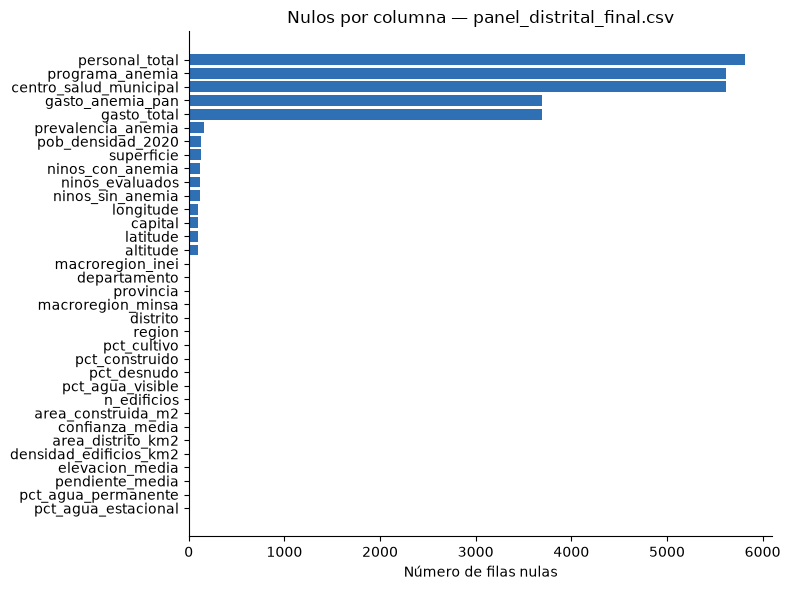

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(resumen_nulos.index[::-1], resumen_nulos["n_nulos"][::-1], color="#2f6fb3")
ax.set_xlabel("Número de filas nulas")
ax.set_title("Nulos por columna — panel_distrital_final.csv")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 3. Duplicados y consistencia interna

**Qué se hace:** verificar que no haya filas duplicadas por la llave `ubigeo + anio`, y que las variables que deberían cuadrar matemáticamente entre sí efectivamente cuadren.

**Por qué:** un duplicado en la llave rompe cualquier análisis a nivel distrito-año (se contaría el mismo distrito dos veces). Y si `ninos_evaluados` no es igual a `ninos_con_anemia + ninos_sin_anemia`, o si `prevalencia_anemia` se sale de `[0, 1]`, hay un problema de cálculo en algún paso anterior del pipeline que hay que resolver antes de seguir — no tendría sentido construir un modelo causal sobre una variable dependiente mal calculada.


In [6]:
n_duplicados = df.duplicated(subset=["ubigeo", "anio"]).sum()
print("Duplicados en ubigeo + anio:", n_duplicados)

chequeo_ninos = df.dropna(subset=["ninos_evaluados", "ninos_con_anemia", "ninos_sin_anemia"])
diferencia = (chequeo_ninos["ninos_evaluados"] - (chequeo_ninos["ninos_con_anemia"] + chequeo_ninos["ninos_sin_anemia"])).abs()
print("Filas donde evaluados != con_anemia + sin_anemia:", (diferencia > 0.01).sum())

fuera_de_rango_prevalencia = df[(df["prevalencia_anemia"] < 0) | (df["prevalencia_anemia"] > 1)]
print("Filas con prevalencia_anemia fuera de [0,1]:", len(fuera_de_rango_prevalencia))

gasto_pan_mayor_total = df[df["gasto_anemia_pan"] > df["gasto_total"]]
print("Filas donde gasto_anemia_pan > gasto_total:", len(gasto_pan_mayor_total))

columnas_pct = ["pct_cultivo", "pct_construido", "pct_desnudo", "pct_agua_visible",
                "pct_agua_permanente", "pct_agua_estacional"]
for col in columnas_pct:
    fuera_de_rango = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col}: {fuera_de_rango} filas fuera de [0,1]")


Duplicados en ubigeo + anio: 0
Filas donde evaluados != con_anemia + sin_anemia: 0
Filas con prevalencia_anemia fuera de [0,1]: 0
Filas donde gasto_anemia_pan > gasto_total: 0
pct_cultivo: 0 filas fuera de [0,1]
pct_construido: 0 filas fuera de [0,1]
pct_desnudo: 0 filas fuera de [0,1]
pct_agua_visible: 0 filas fuera de [0,1]
pct_agua_permanente: 0 filas fuera de [0,1]
pct_agua_estacional: 0 filas fuera de [0,1]


## 4. Corrección 1 — eliminar distritos sin match territorial

**Qué se hace:** identificar y eliminar del panel los ubigeos que no tienen ninguna fila en la geobase territorial (`geobase_distrital.gpkg`), y por lo tanto no tienen ningún dato de contexto satelital.

**Por qué:** el proyecto necesita el contexto territorial (agua, dispersión de viviendas, cobertura de suelo) para todos los distritos que entran al modelo — es la pieza central del argumento causal. Un distrito sin esa información no se puede usar en las etapas de visión por computadora ni en el causal forest, así que no aporta quedarse en el panel a medio llenar.

**Nota para no perder el hallazgo:** estos ubigeos son `130112` (Alto Trujillo, La Libertad) y `180107` (San Antonio, Moquegua). A diferencia del distrito ya excluido en SIAF (`160405`, con solo S/402 mil), estos dos sí tienen gasto ejecutado importante (`180107` acumula ~S/600 millones en el panel). Se eliminan igual por decisión explícita — pero queda registrado acá que no es un descarte "gratis": si en el futuro se consigue georreferenciarlos manualmente, hay presupuesto real que hoy se está dejando fuera del análisis.


In [7]:
ubigeos_sin_match = sorted(df.loc[df["departamento"].isnull(), "ubigeo"].unique())
print("Ubigeos eliminados por no tener match territorial:", ubigeos_sin_match)
print("Filas asociadas a esos ubigeos:", df["ubigeo"].isin(ubigeos_sin_match).sum())
print("Gasto total acumulado que se pierde con esta eliminación (soles):",
      df.loc[df["ubigeo"].isin(ubigeos_sin_match), "gasto_total"].sum())

print("\nFilas antes de eliminar:", df.shape[0])
df = df[~df["ubigeo"].isin(ubigeos_sin_match)].copy()
print("Filas después de eliminar:", df.shape[0])
print("Ubigeos únicos después de eliminar:", df["ubigeo"].nunique())


Ubigeos eliminados por no tener match territorial: ['130112', '180107']
Filas asociadas a esos ubigeos: 9
Gasto total acumulado que se pierde con esta eliminación (soles): 634756232.3199999

Filas antes de eliminar: 13148
Filas después de eliminar: 13139
Ubigeos únicos después de eliminar: 1889


## 5. Corrección 2 — el bug de `"#¡NULO!"` en RENAMU

**Qué se hace:** volver a construir `programa_anemia`, `centro_salud_municipal` y `personal_total` directamente desde las bases crudas de RENAMU (2021-2024), manejando explícitamente el marcador `"#¡NULO!"` como dato faltante.

**Por qué:** en la validación anterior se confirmó que las bases crudas usan el string `"#¡NULO!"` para "sin respuesta" en ciertas preguntas y años. En el pipeline original, este string se coló como si fuera un valor válido y terminó contado como `"No"` (`0`) en vez de como nulo — específicamente en `centro_salud_municipal` de 2022 (1,368 de 1,874 distritos, 73%) y en `programa_anemia` de 2023 (563 de 1,891 distritos, 30%). Eso sesga esas dos variables de control hacia "No" justo en esos años, que es exactamente lo que se quiere evitar en un panel que va a alimentar un modelo causal.


In [8]:
rutas_renamu = {
    2021: DATA / "raw" / "RENAMU" / "2021" / "Base_Renamu_2021_f.csv",
    2022: DATA / "raw" / "RENAMU" / "2022" / "Base_RENAMU_2022_f.csv",
    2023: DATA / "raw" / "RENAMU" / "2023" / "Base-Datos_2023_f.csv",
    2024: DATA / "raw" / "RENAMU" / "2024" / "Base-Datos_2024_f.csv",
}

lista_renamu = []

for anio_encuesta, ruta in rutas_renamu.items():
    renamu_anio = pd.read_csv(ruta, sep=";", encoding="latin1", low_memory=False,
                               usecols=["Ubigeo", "P19D_T", "P68_10", "P66_2"])
    renamu_anio = renamu_anio.rename(columns={"Ubigeo": "ubigeo"})
    renamu_anio["ubigeo"] = renamu_anio["ubigeo"].astype(str).str.zfill(6)

    # pd.to_numeric(..., errors="coerce") convierte "#¡NULO!" (y cualquier otro texto no numérico)
    # directamente en NaN, en vez de dejarlo pasar como si fuera un código válido.
    renamu_anio["personal_total"] = pd.to_numeric(renamu_anio["P19D_T"], errors="coerce")
    renamu_anio["programa_anemia_raw"] = pd.to_numeric(renamu_anio["P68_10"], errors="coerce")
    renamu_anio["centro_salud_municipal_raw"] = pd.to_numeric(renamu_anio["P66_2"], errors="coerce")
    renamu_anio["anio_encuesta"] = anio_encuesta

    lista_renamu.append(renamu_anio[["ubigeo", "anio_encuesta", "personal_total",
                                      "programa_anemia_raw", "centro_salud_municipal_raw"]])

renamu_corregido = pd.concat(lista_renamu, ignore_index=True)

# Recodificación de los códigos oficiales a 0/1:
# P68_10 -> 10 = Sí, 0 = No/Pase        P66_2 -> 1 = Sí, 2 = No
renamu_corregido["programa_anemia"] = renamu_corregido["programa_anemia_raw"].map({0: 0, 10: 1})
renamu_corregido["centro_salud_municipal"] = renamu_corregido["centro_salud_municipal_raw"].map({1: 1, 2: 0})

renamu_corregido.head()


,ubigeo,anio_encuesta,personal_total,programa_anemia_raw,centro_salud_municipal_raw,programa_anemia,centro_salud_municipal
0,010101,2021,208.0,10.0,2.0,1.0,0.0
1,010102,2021,1.0,0.0,2.0,0.0,0.0
2,010103,2021,7.0,10.0,2.0,1.0,0.0
3,010104,2021,5.0,10.0,2.0,1.0,0.0
4,010105,2021,2.0,0.0,2.0,0.0,0.0


**Evidencia del efecto de la corrección:** comparamos la distribución de `centro_salud_municipal` en la encuesta 2022 (donde el bug afectaba directamente al `anio` del panel, sin desfase) contra lo que tenía el panel original, y lo mismo para `programa_anemia` en la encuesta 2023.


In [9]:
print("=== centro_salud_municipal, encuesta 2022 ===")
print("Panel original (bug: NULO contado como 0):")
print(df.loc[df["anio"] == 2022, "centro_salud_municipal"].value_counts(dropna=False))
print("\nCorregido (NULO como NaN):")
print(renamu_corregido.loc[renamu_corregido["anio_encuesta"] == 2022, "centro_salud_municipal"].value_counts(dropna=False))

print("\n=== programa_anemia, encuesta 2023 (antes de aplicar el desfase de año) ===")
print("Corregido (NULO como NaN):")
print(renamu_corregido.loc[renamu_corregido["anio_encuesta"] == 2023, "programa_anemia"].value_counts(dropna=False))


=== centro_salud_municipal, encuesta 2022 ===
Panel original (bug: NULO contado como 0):
centro_salud_municipal
0.0    1706
1.0     168
NaN      15
Name: count, dtype: int64

Corregido (NULO como NaN):
centro_salud_municipal
NaN    1368
0.0     338
1.0     168
Name: count, dtype: int64

=== programa_anemia, encuesta 2023 (antes de aplicar el desfase de año) ===
Corregido (NULO como NaN):
programa_anemia
1.0    838
NaN    563
0.0    490
Name: count, dtype: int64


## 5b. Corrección 3 — desfase de año retrospectivo de RENAMU

**Qué se hace:** `personal_total` y `programa_anemia` son preguntas retrospectivas — la encuesta de un año pregunta por el dato de diciembre del año **anterior**. `centro_salud_municipal` en cambio es una pregunta en tiempo presente, sin desfase. Movemos las dos primeras un año hacia atrás (`anio = anio_encuesta - 1`) y dejamos la tercera tal cual (`anio = anio_encuesta`).

**Por qué:** sin esta corrección, la fila `anio=2021` de `personal_total`/`programa_anemia` describe en realidad diciembre de 2020, pero se estaría comparando contra el gasto y la anemia de 2021 — un desfase de un año que invalidaría cualquier relación causal estimada con esas variables de control. Esto ya estaba identificado como pendiente desde `00g_renamu.ipynb`, nunca se había aplicado en el merge.


In [10]:
personal_y_programa = renamu_corregido[["ubigeo", "anio_encuesta", "personal_total", "programa_anemia"]].copy()
personal_y_programa["anio"] = personal_y_programa["anio_encuesta"] - 1  # preguntas retrospectivas

centro_salud = renamu_corregido[["ubigeo", "anio_encuesta", "centro_salud_municipal"]].copy()
centro_salud["anio"] = centro_salud["anio_encuesta"]  # pregunta en tiempo presente, sin desfase

personal_y_programa = personal_y_programa.drop(columns="anio_encuesta")
centro_salud = centro_salud.drop(columns="anio_encuesta")

renamu_final = personal_y_programa.merge(centro_salud, on=["ubigeo", "anio"], how="outer")

print("Rango de anio en renamu_final tras el desfase:")
print(sorted(renamu_final["anio"].unique()))
renamu_final.head()


Rango de anio en renamu_final tras el desfase:
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,ubigeo,personal_total,programa_anemia,anio,centro_salud_municipal
0,010101,208.0,1.0,2020,NaN
1,010101,198.0,0.0,2021,0.0
2,010101,206.0,1.0,2022,0.0
3,010101,268.0,1.0,2023,0.0
4,010101,NaN,NaN,2024,0.0


**Aplicamos el reemplazo en el panel:** se eliminan las tres columnas originales (con el bug de decodificación y sin el desfase de año) y se pegan las versiones corregidas.

**Ojo:** el número de nulos de estas tres columnas va a **subir** respecto al panel original — eso es lo esperado, no un error nuevo. Antes, los `"#¡NULO!"` sin respuesta estaban disfrazados de `"No"` (0), lo que hacía parecer que había menos nulos de los que en realidad había. Al corregirlo, esas filas pasan a `NaN` correctamente, así que el conteo de nulos sube pero ahora refleja la realidad de los datos.


In [11]:
df = df.drop(columns=["personal_total", "programa_anemia", "centro_salud_municipal"])
df = df.merge(renamu_final, on=["ubigeo", "anio"], how="left")

print("Nulos después de la corrección:")
print(df[["personal_total", "programa_anemia", "centro_salud_municipal"]].isnull().sum())
print()
print("Nota: el rango de años con dato ahora es distinto al original (2021-2024) porque")
print("personal_total y programa_anemia se corrieron un año hacia atrás -> ahora cubren 2020-2023.")
print(sorted(df.loc[df["personal_total"].notnull(), "anio"].unique()))


Nulos después de la corrección:
personal_total            5857
programa_anemia           6228
centro_salud_municipal    6981
dtype: int64

Nota: el rango de años con dato ahora es distinto al original (2021-2024) porque
personal_total y programa_anemia se corrieron un año hacia atrás -> ahora cubren 2020-2023.
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


## 6. `region` — documentado, no corregido

**Qué se hace:** confirmar en código qué es realmente `region`, comparándola contra `departamento`, y dejarlo documentado en el propio panel en vez de solo en un archivo aparte.

**Por qué no se corrige acá:** el diccionario de datos describe `region` como "costa/sierra/selva u homóloga", pero la columna real tiene 26 valores. No es una copia exacta de `departamento` (25 valores): el 91% de las filas coinciden, y el 100% de las que no coinciden son distritos de `departamento = "LIMA"`, donde `region` toma en cambio el valor `"LIMA PROVINCIA"` o `"LIMA REGION"` (dos etiquetas distintas, no una sola) para separar la provincia de Lima Metropolitana del resto de provincias del departamento. Es decir, `region` es esencialmente `departamento` con una distinción adicional dentro de Lima — sigue sin ser costa/sierra/selva, y además usa dos nombres distintos (`"LIMA PROVINCIA"` y `"LIMA REGION"`) para lo que podría ser la misma idea, algo que valdría la pena revisar si esta columna se termina usando en el modelo. Construir la clasificación natural real (costa/sierra/selva) requeriría una fuente adicional (tabla de clasificación por distrito) que no forma parte de este EDA — se deja como pendiente explícito, no se inventa el dato ni se borra la columna.


In [12]:
es_igual_a_departamento = (df["region"] == df["departamento"]).mean()
print(f"Porcentaje de filas donde region == departamento: {es_igual_a_departamento:.1%}")

diferencias = df.loc[df["region"] != df["departamento"], ["departamento", "region"]].drop_duplicates()
print("\nCasos donde difieren (departamento -> region):")
print(diferencias.to_string(index=False))

print("\nValores únicos de 'region':", df["region"].nunique(), "(se esperarían 3 si fuera costa/sierra/selva)")


Porcentaje de filas donde region == departamento: 91.0%

Casos donde difieren (departamento -> region):
departamento         region
        LIMA LIMA PROVINCIA
        LIMA    LIMA REGION

Valores únicos de 'region': 26 (se esperarían 3 si fuera costa/sierra/selva)


## 7. Outliers

**Qué se hace:** usar el método IQR (rango intercuartílico) sobre las variables numéricas más relevantes para el argumento del proyecto, y mirar cuáles son los distritos en los extremos.

**Por qué:** un outlier en este contexto no es necesariamente un error — puede ser Lima Metropolitana con una densidad de edificios enorme, que es real. La idea de este paso no es borrar outliers automáticamente, sino identificarlos y decidir caso por caso si son datos reales (dejarlos) o errores de fuente (investigarlos).

Separamos en dos grupos: variables de contexto territorial (una fila por distrito, se repiten en cada año — hay que deduplicar antes de mirar outliers) y variables que sí varían por año (gasto y prevalencia de anemia).


In [13]:
variables_territoriales = ["n_edificios", "densidad_edificios_km2", "pob_densidad_2020",
                           "elevacion_media", "pendiente_media"]

df_un_distrito_por_fila = df.drop_duplicates(subset="ubigeo")[["ubigeo", "distrito"] + variables_territoriales]

for col in variables_territoriales:
    q1 = df_un_distrito_por_fila[col].quantile(0.25)
    q3 = df_un_distrito_por_fila[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    es_outlier = (df_un_distrito_por_fila[col] < limite_inferior) | (df_un_distrito_por_fila[col] > limite_superior)
    print(f"{col}: {es_outlier.sum()} distritos fuera de [{limite_inferior:.1f}, {limite_superior:.1f}]")

    top_outliers = df_un_distrito_por_fila.loc[es_outlier].sort_values(col, ascending=False).head(3)
    print(top_outliers[["distrito", col]].to_string(index=False))
    print()


n_edificios: 205 distritos fuera de [-10678.0, 22730.0]
              distrito  n_edificios
SAN JUAN DE LURIGANCHO     370453.0
        CERRO COLORADO     203231.0
                   ATE     202986.0

densidad_edificios_km2: 259 distritos fuera de [-58.9, 117.3]
                     distrito  densidad_edificios_km2
                   BELLAVISTA             6613.444949
            FLORENCIA DE MORA             5351.874960
JOSE LUIS BUSTAMANTE Y RIVERO             4615.237413

pob_densidad_2020: 253 distritos fuera de [-65.2, 127.9]
         distrito  pob_densidad_2020
            BREÑA       41155.900621
FLORENCIA DE MORA       35670.351759
        SURQUILLO       35535.838150

elevacion_media: 0 distritos fuera de [-2654.7, 7745.4]
Empty DataFrame
Columns: [distrito, elevacion_media]
Index: []

pendiente_media: 0 distritos fuera de [-6.6, 43.1]
Empty DataFrame
Columns: [distrito, pendiente_media]
Index: []



In [14]:
variables_panel = ["gasto_total", "prevalencia_anemia"]

for col in variables_panel:
    datos_col = df.dropna(subset=[col])
    q1 = datos_col[col].quantile(0.25)
    q3 = datos_col[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    es_outlier = (datos_col[col] < limite_inferior) | (datos_col[col] > limite_superior)
    print(f"{col}: {es_outlier.sum()} filas (distrito-año) fuera de [{limite_inferior:.2f}, {limite_superior:.2f}]")

    top_outliers = datos_col.loc[es_outlier].sort_values(col, ascending=False).head(3)
    print(top_outliers[["distrito", "anio", col]].to_string(index=False))
    print()


gasto_total: 1453 filas (distrito-año) fuera de [-22533594.21, 46295893.23]
distrito  anio  gasto_total
    LIMA  2025 7.141695e+10
    LIMA  2024 6.819234e+10
    LIMA  2023 6.202975e+10

prevalencia_anemia: 589 filas (distrito-año) fuera de [-0.31, 0.78]
 distrito  anio  prevalencia_anemia
   TICACO  2023                 1.0
   TICACO  2020                 1.0
TARUCACHI  2020                 1.0



**Hallazgo relevante para el resto del proyecto:** los outliers de `prevalencia_anemia` no son un problema de captura de dato — son un problema de tamaño de muestra. Comprobamos abajo cuántos `ninos_evaluados` tienen en promedio las filas marcadas como outlier de prevalencia, comparado con el panel completo. Si son pocos niños evaluados, un solo caso de anemia puede mover la prevalencia de 0% a 100% sin que eso refleje la situación real del distrito. Esto es exactamente la razón por la que el documento maestro del proyecto propone un modelo bayesiano de corrección de sesgo con incertidumbre explícita, en vez de tomar `prevalencia_anemia` tal cual como variable dependiente.


In [15]:
datos_prev = df.dropna(subset=["prevalencia_anemia", "ninos_evaluados"])
q1 = datos_prev["prevalencia_anemia"].quantile(0.25)
q3 = datos_prev["prevalencia_anemia"].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
son_outliers = (datos_prev["prevalencia_anemia"] < limite_inferior) | (datos_prev["prevalencia_anemia"] > limite_superior)

print("Mediana de ninos_evaluados en filas outlier de prevalencia_anemia:",
      datos_prev.loc[son_outliers, "ninos_evaluados"].median())
print("Mediana de ninos_evaluados en el panel completo:",
      datos_prev["ninos_evaluados"].median())


Mediana de ninos_evaluados en filas outlier de prevalencia_anemia: 14.0
Mediana de ninos_evaluados en el panel completo: 80.0


Visualizamos los mismos grupos con boxplots — más fácil de interpretar de un vistazo que la lista de números.


C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_33184\1956980172.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df_un_distrito_por_fila[col].dropna(), vert=True,
C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_33184\1956980172.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df_un_distrito_por_fila[col].dropna(), vert=True,
C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_33184\1956980172.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df_un_distrito_por_fila[col].dropna(), vert=True,
C:\Users\JHOSSEP\AppData\Local\Temp\ipykernel_33184\1956980172.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matpl

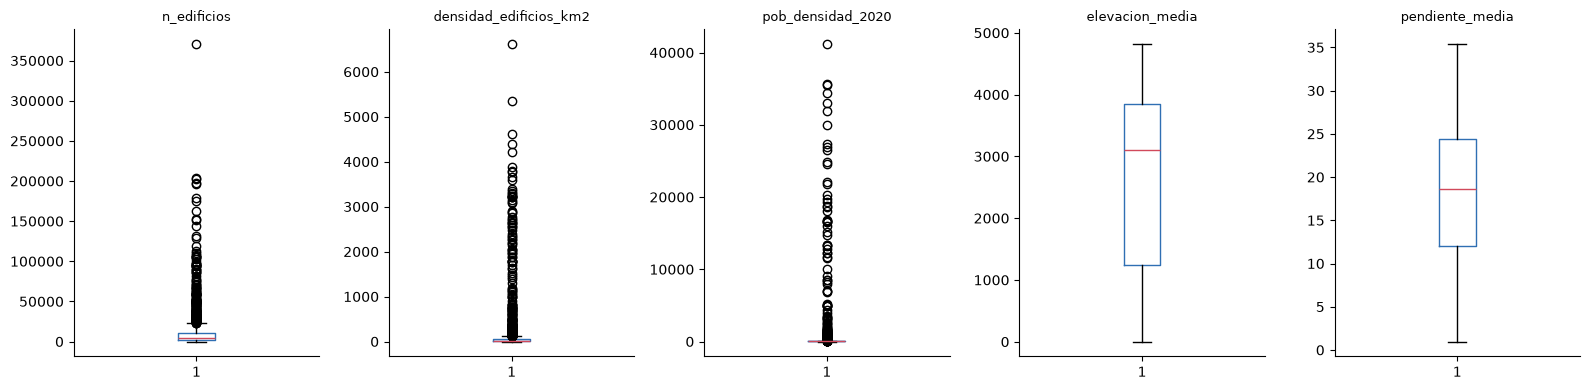

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, variables_territoriales):
    ax.boxplot(df_un_distrito_por_fila[col].dropna(), vert=True,
               boxprops=dict(color="#2f6fb3"), medianprops=dict(color="#d1495b"))
    ax.set_title(col, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 8. Distribuciones

**Qué se hace:** histogramas de las variables clave para el modelo causal.

**Por qué:** ver qué tan sesgada está cada variable importa para las siguientes etapas del proyecto — el gasto público, por ejemplo, casi siempre tiene una distribución muy asimétrica (muchos distritos con poco gasto, pocos con mucho), y eso puede requerir una transformación logarítmica antes de entrar al Double Machine Learning / Causal Forest. Acá solo diagnosticamos, no transformamos todavía.


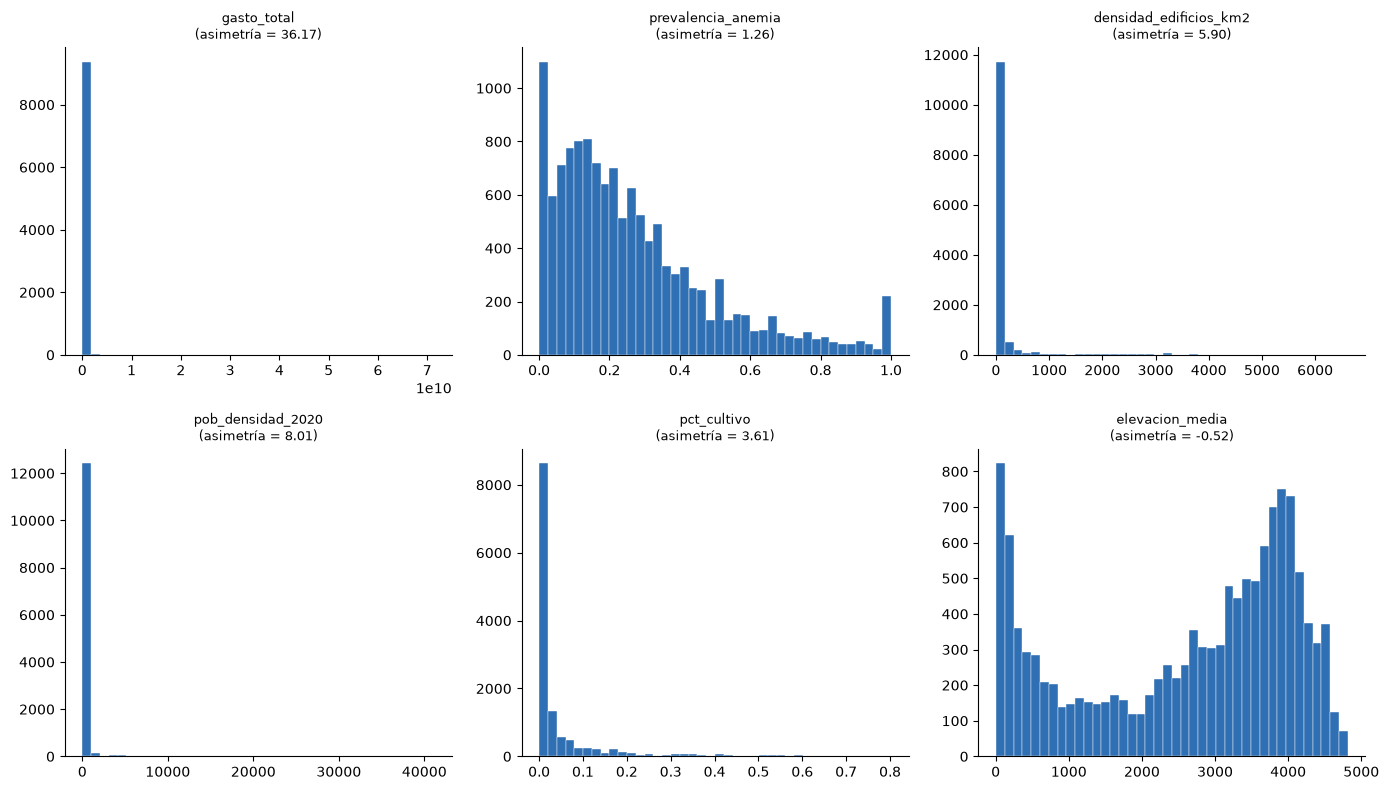

In [17]:
variables_histograma = ["gasto_total", "prevalencia_anemia", "densidad_edificios_km2",
                        "pob_densidad_2020", "pct_cultivo", "elevacion_media"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, variables_histograma):
    ax.hist(df[col].dropna(), bins=40, color="#2f6fb3", edgecolor="white", linewidth=0.3)
    asimetria = df[col].dropna().skew()
    ax.set_title(f"{col}\n(asimetría = {asimetria:.2f})", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 9. Relaciones simples: gasto vs. anemia

**Qué se hace:** un scatter simple de gasto vs. prevalencia de anemia, y una matriz de correlación entre las variables numéricas del panel.

**Por qué:** este es el punto que justifica todo el enfoque causal del proyecto. Si la correlación cruda entre gasto y anemia sale positiva (más gasto asociado a más anemia), no significa que el gasto cause anemia — significa que el Estado gasta más donde ya hay más anemia. Verlo acá, de forma simple y directa, es la evidencia visual de por qué una regresión ingenua sería engañosa y de por qué el proyecto usa Double Machine Learning / Causal Forest en vez de una correlación directa.


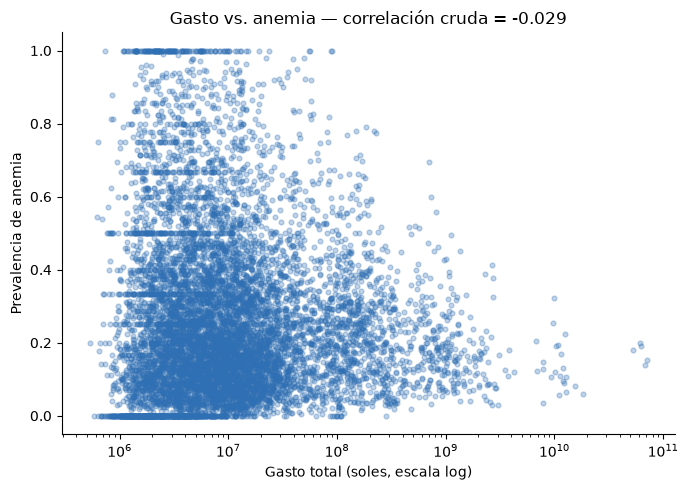

Correlación cruda gasto_total vs prevalencia_anemia: -0.029
Sea cual sea el signo o la magnitud de este número, no se puede leer como causal:
el gasto y la anemia están confundidos por el mismo territorio (el Estado no gasta al azar),
así que una correlación cercana a 0 tampoco significa 'el gasto no sirve' — puede estar
ocultando efectos positivos en unos distritos y negativos en otros. Esa heterogeneidad es
exactamente lo que el Double Machine Learning / Causal Forest del proyecto busca destrabar.


In [18]:
datos_scatter = df.dropna(subset=["gasto_total", "prevalencia_anemia"])
correlacion = datos_scatter["gasto_total"].corr(datos_scatter["prevalencia_anemia"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(datos_scatter["gasto_total"], datos_scatter["prevalencia_anemia"],
           alpha=0.3, s=12, color="#2f6fb3")
ax.set_xscale("log")
ax.set_xlabel("Gasto total (soles, escala log)")
ax.set_ylabel("Prevalencia de anemia")
ax.set_title(f"Gasto vs. anemia — correlación cruda = {correlacion:.3f}")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Correlación cruda gasto_total vs prevalencia_anemia: {correlacion:.3f}")
print("Sea cual sea el signo o la magnitud de este número, no se puede leer como causal:")
print("el gasto y la anemia están confundidos por el mismo territorio (el Estado no gasta al azar),")
print("así que una correlación cercana a 0 tampoco significa 'el gasto no sirve' — puede estar")
print("ocultando efectos positivos en unos distritos y negativos en otros. Esa heterogeneidad es")
print("exactamente lo que el Double Machine Learning / Causal Forest del proyecto busca destrabar.")


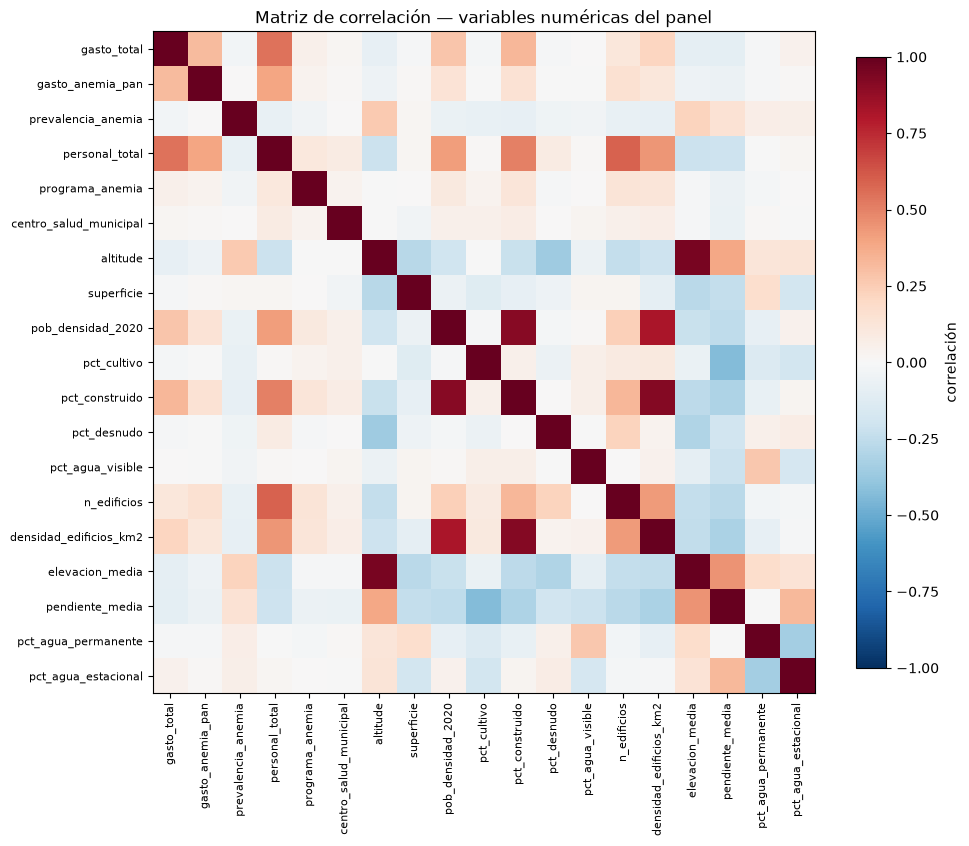

In [19]:
columnas_correlacion = [
    "gasto_total", "gasto_anemia_pan", "prevalencia_anemia", "personal_total",
    "programa_anemia", "centro_salud_municipal", "altitude", "superficie",
    "pob_densidad_2020", "pct_cultivo", "pct_construido", "pct_desnudo",
    "pct_agua_visible", "n_edificios", "densidad_edificios_km2",
    "elevacion_media", "pendiente_media", "pct_agua_permanente", "pct_agua_estacional",
]

matriz_corr = df[columnas_correlacion].corr()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(matriz_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_correlacion)))
ax.set_yticks(range(len(columnas_correlacion)))
ax.set_xticklabels(columnas_correlacion, rotation=90, fontsize=8)
ax.set_yticklabels(columnas_correlacion, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlación")
ax.set_title("Matriz de correlación — variables numéricas del panel")
plt.tight_layout()
plt.show()


## 10. Cierre — guardar el panel limpio

**Qué se hace:** guardar el resultado en un archivo nuevo (`panel_distrital_clean.csv`), sin sobrescribir el `_final.csv` original.

**Por qué un archivo nuevo y no sobrescribir:** mantener `panel_distrital_final.csv` intacto preserva la trazabilidad del pipeline — si algo de esta limpieza necesita revisarse o revertirse más adelante, el archivo de entrada original sigue disponible tal como lo produjo `00a_mergue_database.ipynb`.


In [23]:
df.to_csv(CLEAN_CSV_PATH, index=False)
print("Guardado en:", CLEAN_CSV_PATH)
print("Shape final:", df.shape)


Guardado en: c:\Users\JHOSSEP\Documents\REPO\causal-anemia-model\data\clean\panel_distrital.csv
Shape final: (13139, 36)


### Resumen de lo aplicado en este notebook

1. **Eliminados** los 2 ubigeos sin match territorial (`130112`, `180107` — 9 filas), dejando explícito que esto descarta gasto real no marginal (~S/600 millones en el caso de `180107`).
2. **Corregido** el bug de decodificación de `"#¡NULO!"` en `programa_anemia` (2023) y `centro_salud_municipal` (2022), que los codificaba como "No" en vez de dato faltante.
3. **Aplicado** el desfase de año retrospectivo de RENAMU (`personal_total`, `programa_anemia` → `anio_encuesta - 1`), pendiente desde `00g_renamu.ipynb`.
4. **Documentado** (sin modificar) que `region` es una copia de `departamento`, no una clasificación costa/sierra/selva.
5. **Revisados** duplicados, consistencia interna, outliers y distribuciones — sin encontrar errores adicionales de cálculo.

### Pendientes que este notebook no resuelve (quedan para otra etapa)

- Sesgo de selección de anemia (ENDES) — sección 5 del documento maestro, todavía no tocado en ningún notebook.
- Normalización de `gasto_total`/`gasto_anemia_pan` por población infantil (requiere el Padrón Nominal de REUNIS).
- Clasificación real costa/sierra/selva para reemplazar el uso actual de `region`.
- Ampliar `gasto_anemia_pan` más allá de PAN (0001) a los demás programas con incidencia en anemia.
- Incorporar la serie NDVI (`00d_ndvi_extraction.ipynb`), todavía no generada.
